In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('monthly_milk_production.csv')
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [4]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [5]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [6]:
df['Date']=pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


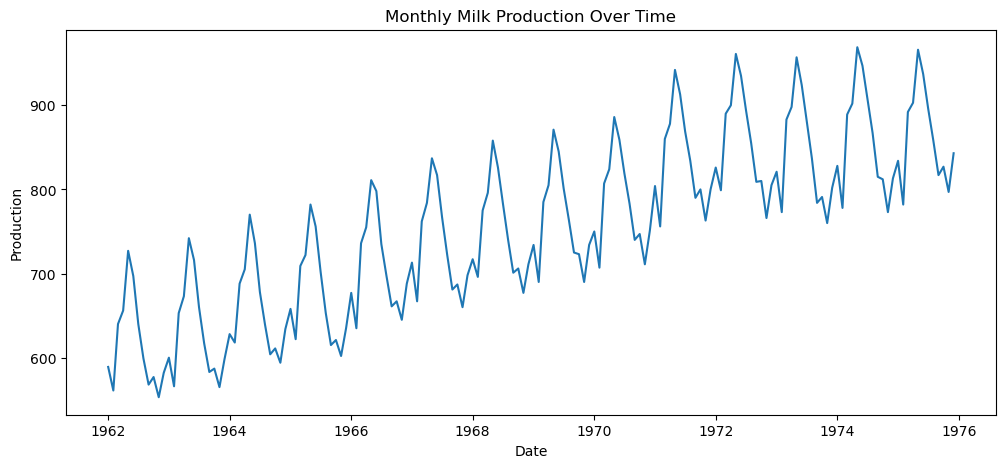

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Production'])
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production')
plt.show()

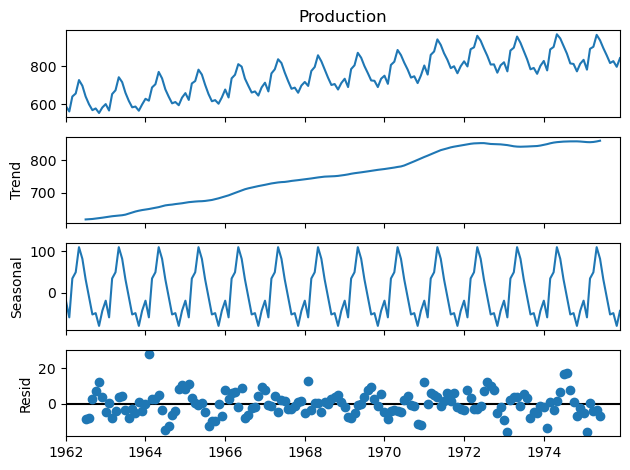

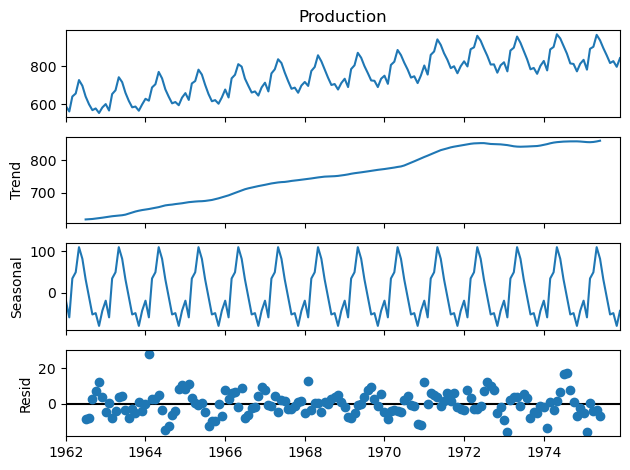

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
# decompose data
res=seasonal_decompose(df['Production'],model='additive',period=12)
res.plot()

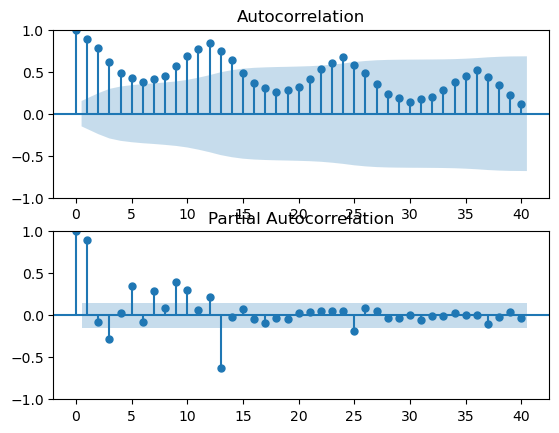

In [10]:
# ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig,ax=plt.subplots(2, 1)
plot_acf(df['Production'],lags=40,ax=ax[0])
plot_pacf(df['Production'],lags=40,ax=ax[1])
plt.show()

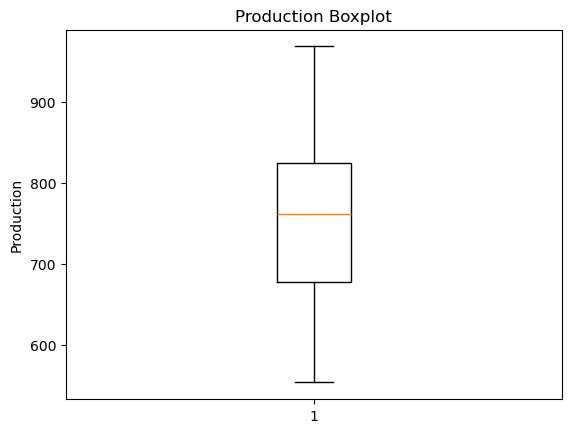

In [12]:
# boxplot to check for outliers
plt.boxplot(df['Production'])
plt.title('Production Boxplot')
plt.ylabel('Production')
plt.show()

# trend going up
# seasonal pattern visible
# data looks clean

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df['scaled']=scaler.fit_transform(df['Production'].values.reshape(-1,1))
df.head()

,Production,scaled
Date,,
1962-01-01,589,0.086538
1962-02-01,561,0.019231
1962-03-01,640,0.209135
1962-04-01,656,0.247596
1962-05-01,727,0.418269


# Data Preparation


In [14]:
def create_sequences(data,lb):
    X,y=[],[]
    for i in range(len(data)-lb):
        X.append(data[i:i+lb])
        y.append(data[i+lb])
    return np.array(X),np.array(y)
X,y=create_sequences(df['scaled'].values,12)
print(X.shape, y.shape)

(156, 12) (156,)


In [16]:
train=int(len(X)*0.7)
val=int(len(X)*0.15)

In [17]:
X_train,y_train=X[:train],y[:train]
X_val,y_val=X[train:train+val],y[train:train+val]
X_test,y_test=X[train+val:],y[train+val:]

In [18]:
X_train=X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val=X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test=X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [19]:
print(X_train.shape,X_val.shape,X_test.shape)

(109, 12, 1) (23, 12, 1) (24, 12, 1)


# Model Building

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [21]:
rnn=Sequential([SimpleRNN(50,input_shape=(look_back,1)),Dense(1)])
rnn.compile('adam', 'mse')
rnn.summary()

C:\Users\shiva\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history_rnn=rnn.fit(X_train,y_train,epochs=50,batch_size=32,validation_data=(X_val,y_val),verbose=0)
print("RNN training done")

RNN training done


In [25]:
lstm=Sequential([LSTM(50,input_shape=(look_back,1)),Dense(1)])
lstm.compile('adam','mse')
lstm.fit(X_train,y_train,epochs=20,verbose=0)

C:\Users\shiva\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
gru=Sequential([GRU(50,input_shape=(look_back,1)),Dense(1)])
gru.compile('adam','mse')
gru.fit(X_train,y_train,epochs=20,verbose=0)

C:\Users\shiva\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Model Evaluation

In [28]:
y_test_inv=scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_rnn=scaler.inverse_transform(rnn.predict(X_test))
y_pred_lstm=scaler.inverse_transform(lstm.predict(X_test))
y_pred_gru=scaler.inverse_transform(gru.predict(X_test))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mape(a,p):
    return np.mean(np.abs((a-p)/a))*100

for name,pred in [('RNN',y_pred_rnn),('LSTM',y_pred_lstm),('GRU',y_pred_gru)]:
    rmse=np.sqrt(mean_squared_error(y_test_inv,pred))
    mae=mean_absolute_error(y_test_inv,pred)
    mp=mape(y_test_inv,pred)
    print(name,"RMSE:",round(rmse,2),"MAE:",round(mae,2),"MAPE:",round(mp,2))

RNN RMSE: 24.19 MAE: 19.49 MAPE: 2.27
LSTM RMSE: 71.04 MAE: 56.73 MAPE: 6.37
GRU RMSE: 72.39 MAE: 55.08 MAPE: 6.12


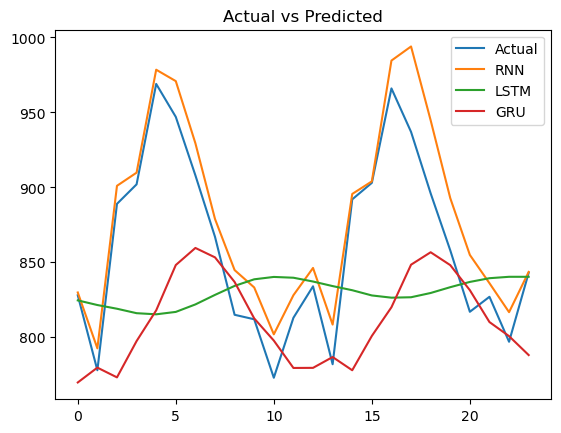

In [30]:
plt.figure()
plt.plot(y_test_inv,label='Actual')
plt.plot(y_pred_rnn,label='RNN')
plt.plot(y_pred_lstm,label='LSTM')
plt.plot(y_pred_gru,label='GRU')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

# Forecasting Next 12 Months

In [32]:
last_seq=df['scaled'].values[-look_back:]
future_dates=pd.date_range(start=df.index[-1]+pd.DateOffset(months=1),periods=12,freq='MS')
def forecast_12(model,seed):
    preds=[]
    seq=list(seed)

    for i in range(12):
        x=np.array(seq[-look_back:]).reshape(1,look_back,1)
        y=model.predict(x,verbose=0)[0][0]

        preds.append(y)
        seq.append(y)

    return scaler.inverse_transform(np.array(preds).reshape(-1, 1))

# predictions
rnn_fc=forecast_12(rnn,last_seq)
lstm_fc=forecast_12(lstm,last_seq)
gru_fc=forecast_12(gru,last_seq)

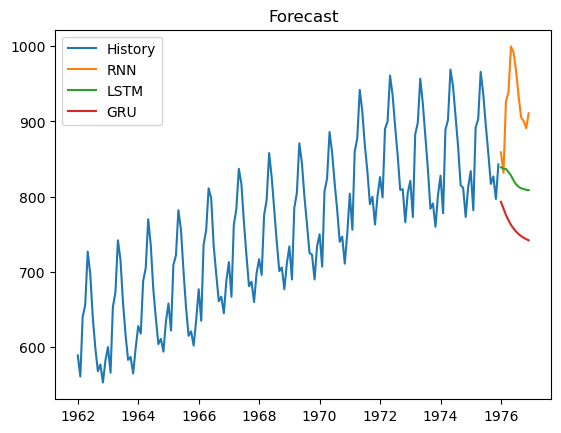

In [34]:
plt.figure()
plt.plot(df.index,df['Production'],label='History')
plt.plot(future_dates,rnn_fc,label='RNN')
plt.plot(future_dates,lstm_fc,label='LSTM')
plt.plot(future_dates,gru_fc,label='GRU')
plt.title('Forecast')
plt.legend()
plt.show()

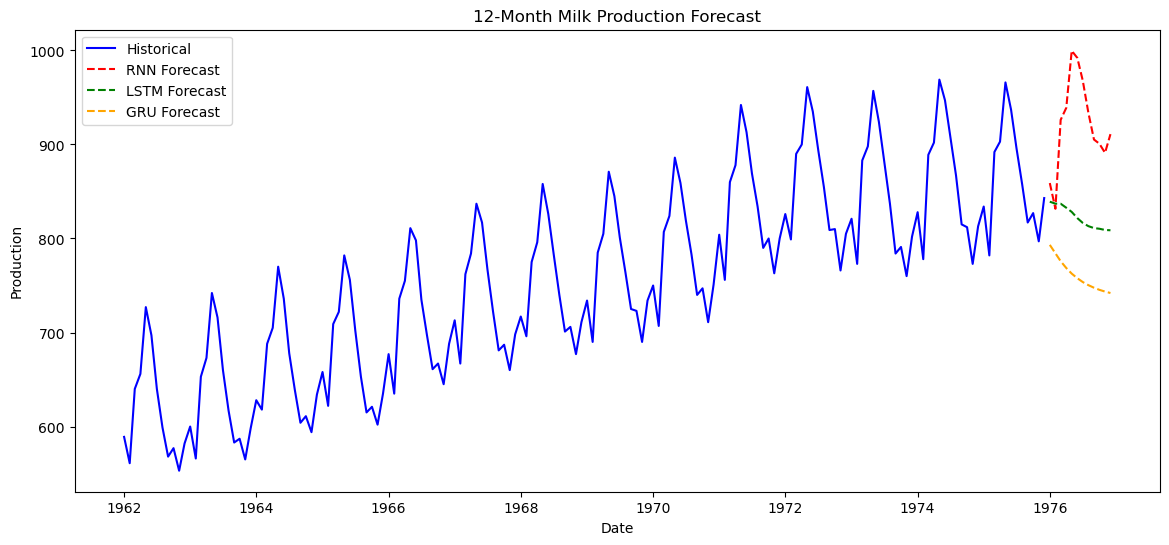

In [36]:
plt.figure(figsize=(14, 6))
plt.plot(df.index,df['Production'],label='Historical',color='blue')
plt.plot(future_dates,rnn_fc,label='RNN Forecast',color='red',linestyle='--')
plt.plot(future_dates,lstm_fc,label='LSTM Forecast',color='green',linestyle='--')
plt.plot(future_dates,gru_fc,label='GRU Forecast',color='orange',linestyle='--')
plt.title('12-Month Milk Production Forecast')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.show()

In [39]:
forecast_df = pd.DataFrame({'Date': future_dates, 'RNN': rnn_fc.flatten(),'LSTM':lstm_fc.flatten(),'GRU':gru_fc.flatten()})
forecast_df

,Date,RNN,LSTM,GRU
0,1976-01-01,858.971680,839.126160,793.201904
1,1976-02-01,831.621948,837.048645,784.220703
2,1976-03-01,926.202759,836.972778,775.802246
3,1976-04-01,939.013672,832.702698,768.611877
4,1976-05-01,999.717102,828.266907,762.644531
5,1976-06-01,992.083496,821.710022,757.730408
6,1976-07-01,967.992310,816.582703,753.691711
7,1976-08-01,933.790405,813.131592,750.371643
8,1976-09-01,905.246704,811.061584,747.640015
9,1976-10-01,900.784973,810.363953,745.391235
